In [1]:
import sys
import os

sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models')

import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a depende

In [2]:
X1 = pd.read_csv("mod_data/X1.1", index_col="QSPRID")
X2 = pd.read_csv("mod_data/X2.1", index_col="QSPRID")
X3 = pd.read_csv("mod_data/X3.1", index_col="QSPRID")
y1 = pd.read_csv("mod_data/y1.1", index_col="QSPRID")
y2 = pd.read_csv("mod_data/y2.1", index_col="QSPRID")
y3 = pd.read_csv("mod_data/y3.1", index_col="QSPRID")


In [3]:
X1

,300,301,302,303,304,305,306,307,308,309,...,RDkit_fr_priamide,RDkit_fr_pyridine,RDkit_fr_sulfide,RDkit_fr_sulfonamd,RDkit_fr_sulfone,RDkit_fr_thiazole,RDkit_fr_thiophene,RDkit_fr_unbrch_alkane,RDkit_fr_urea,RDkit_qed
QSPRID,,,,,,,,,,,,,,,,,,,,,
A2ARDataset_0000,-0.308563,0.516990,0.283642,0.266294,-0.247365,-1.128524,0.309840,-0.524603,-0.147377,-0.032262,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.719563
A2ARDataset_0001,-0.155300,0.636047,0.227501,0.038977,0.000860,-0.772830,0.972226,0.031980,0.480479,0.239048,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.173447
A2ARDataset_0002,-0.723099,0.587804,0.056007,0.356455,-0.079368,-0.746009,0.682991,-0.369075,-0.278554,-0.152143,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.897659
A2ARDataset_0003,-0.129878,0.716170,0.359885,-0.407336,-0.058970,-1.122444,0.639601,-0.035885,0.156267,0.133295,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.281880
A2ARDataset_0004,-0.366854,0.472275,0.327102,0.380823,-0.178509,-1.128237,0.387270,-0.324224,-0.027483,-0.075962,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.705221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2ARDataset_2402,-0.320582,0.624884,0.077183,0.139234,0.043471,-0.632272,0.603211,0.004710,0.099075,0.059412,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.418088
A2ARDataset_2403,-0.782738,0.409371,0.360127,-0.001428,0.037057,-0.815762,0.657149,0.014185,0.876741,0.191767,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.375281
A2ARDataset_2404,-0.126299,0.349761,0.088746,-0.017066,0.356339,-0.644341,0.443447,-0.405881,0.233072,0.084093,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.530334


In [4]:
X1.columns = X1.columns.astype(str)
X2.columns = X2.columns.astype(str)
X3.columns = X3.columns.astype(str)

imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [5]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
pca.fit(X1)


PCA(n_components=0.95)

In [6]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Např. najít počet komponent, které vysvětlí 95 % rozptylu
n_components = np.argmax(cum_var >= 0.95) + 1

In [7]:
pca = PCA(n_components=n_components)
X1 = pca.fit_transform(X1)
X2 = pca.transform(X2)
X3 = pca.transform(X3)

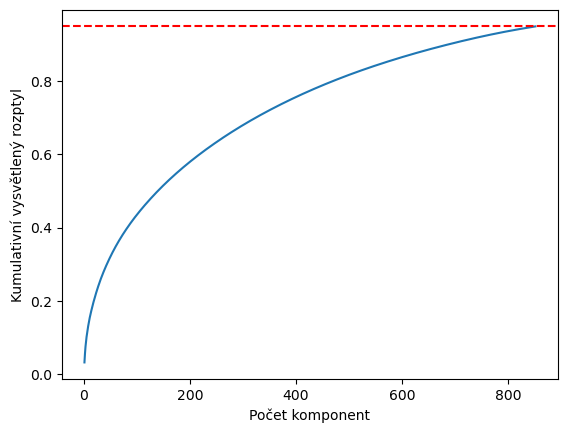

In [8]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlený rozptyl')
plt.show()

In [9]:
import lightgbm as lgb

rf = lgb.LGBMClassifier( random_state=69)
rf.fit(X1, y1)

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


[LightGBM] [Info] Number of positive: 2317, number of negative: 90
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.331725 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 217005
[LightGBM] [Info] Number of data points in the train set: 2407, number of used features: 851
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.962609 -> initscore=3.248219
[LightGBM] [Info] Start training from score 3.248219
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier(random_state=69)

In [10]:
pred = rf.predict(X2)

In [11]:
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score

print("Acc:", accuracy_score(pred, y2))
print("Mcc:", matthews_corrcoef(pred, y2))

Acc: 0.9630086313193588
Mcc: 0.0


In [12]:
pred = rf.predict(X3)
print("Acc:", accuracy_score(pred, y3))
print("Mcc:", matthews_corrcoef(pred, y3))

Acc: 0.9641203703703703
Mcc: -0.006456129070445833


In [13]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score, roc_auc_score # Přidáme import pro ROC AUC
import pandas as pd
import optuna



def objective(trial, X_train, y_train, X_val, y_val):
    """Definice cílové funkce pro Optunu"""

    # Návrh hyperparametrů
    params = {
        'objective': 'binary',
        'metric': 'auc',  # Používáme AUC pro optimalizaci
        'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt', 'dart']),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'max_depth': trial.suggest_int('max_depth', 5, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.8, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.8, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 0.1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 0.1),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'verbose': -1,  # Potlačení logování
        'random_state': 69,  # Přidáno pro reprodukovatelnost
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train.Y)
    y_pred = model.predict(X_val)
    mcc = matthews_corrcoef(y_val.Y, y_pred)  # Používáme MCC

    return mcc


In [ ]:
study = optuna.create_study(
    study_name="A2AR_lgb_without_smote",  # jméno pro pozdější načtení
    direction="maximize",
    sampler=optuna.samplers.NSGAIISampler(),
    storage="sqlite:///optuna_results.db",
    load_if_exists=True  # pokud už existuje, nepřepíše ji
)

# Spusť optimalizaci
study.optimize(
    lambda trial: objective(trial, X1, y1, X2, y2),
    n_trials=2000
)
print("Best MCC:", study.best_value)
print("Best parameters:", study.best_params)

# Pokud chceš F1 a ACC u nejlepšího modelu:
print("Best F1:", study.best_trial.user_attrs["f1"])
print("Best ACC:", study.best_trial.user_attrs["acc"])

[I 2025-05-19 22:03:56,982] A new study created in RDB with name: A2AR_lgb_without_smote


In [ ]:
import numpy as np
best_params = study.best_params

In [ ]:
best_params

In [ ]:
rf = lgb.LGBMClassifier(**best_params, seed=69)
rf.fit(X1, y1.Y)

In [ ]:
pred = rf.predict(X2)

print("Acc:", accuracy_score(pred, y2))
print("F1:", f1_score(pred, y2))
print("Mcc:", matthews_corrcoef(pred, y2))

In [ ]:
pred_test = rf.predict(X3)

print("Acc:", accuracy_score(pred_test, y3))
print("F1:", f1_score(pred_test, y3))
print("Mcc:", matthews_corrcoef(pred_test, y3))